# Exploratory Figure — Condition Separability in Wi-Fi CSI Data

**Project**: Device-free presence detection via Wi-Fi CSI with ESP32-S3
**Dataset**: Pilot collection — Sessions C (empty), D (occupied still), E (occupied moving), F (empty)

This notebook produces a publication-quality exploratory figure comparing three
presence conditions using Channel State Information (CSI) data collected with
ESP32-S3 in HT40 mode (40 MHz, channel 11, ~30 Hz).

## Figure layout
1. **Upper panel** — Temporal median of CSI amplitude aggregated across the 162
   shared valid subcarriers, with an IQR shaded band representing the **temporal
   spread** of that median signal within a rolling window.
2. **Lower panel** — Median Absolute Deviation (MAD) aggregated over non-overlapping
   2.0-second windows (median across subcarriers).

## IQR band definition (v2 — corrected)

> **Why the original cross-subcarrier IQR was wrong**
>
> The first version computed Q25/Q75 *across the 162 subcarriers* at each sample,
> capturing channel frequency-selectivity (some subcarriers are very low-amplitude
> even when valid). For session C (empty, LOS-dominated) this produced
> `Q25 ≈ 7.6` despite `median ≈ 40` — an IQR of 42.6, wider than the median itself.
>
> **Corrected approach**: the band is the *temporal* IQR of the scalar
> `median_amp[t]` signal within a rolling window of `SMOOTH_WINDOW` samples.
> All three statistics (median, Q25, Q75) are computed from the **same scalar
> series** via the **same rolling window** → consistent aggregation unit.
> The band width reflects channel stability: narrow for the empty condition
> (median barely moves), wider for the moving condition.

| Parameter | Value |
|-----------|-------|
| Protocol | ESP-NOW HT40 (802.11n, 40 MHz, ch 11) |
| Sample rate | ~30 Hz |
| Total subcarriers | 192 complex (384 interleaved I/Q integers) |
| Shared valid subcarriers | 162 (intersection C∩D∩E∩F) |
| Active window per session | 600 s |
| MAD segmentation window | 2.0 s (non-overlapping) |
| Rolling window (IQR band) | 30 samples (~1 s at 30 Hz) |


In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import json
import ast
import re
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# Figure aesthetics — publication quality
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'figure.facecolor':  'white',
    'axes.facecolor':    '#fafafa',
    'axes.edgecolor':    '#444444',
    'axes.linewidth':    0.8,
    'grid.alpha':        0.4,
    'grid.linestyle':    '--',
    'grid.linewidth':    0.6,
    'legend.framealpha': 0.93,
    'legend.edgecolor':  '#cccccc',
    'legend.fontsize':   10,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'axes.labelsize':    11,
    'axes.titlesize':    12,
})
print("Imports OK | matplotlib", matplotlib.__version__, "| pandas", pd.__version__)


Imports OK | matplotlib 3.10.8 | pandas 3.0.2


In [2]:
# GLOBAL CONFIGURATION

# Locate repository root (walk up until pilot/data/ is found)
REPO_ROOT = Path.cwd()
for _ in range(10):
    if (REPO_ROOT / 'pilot' / 'data').exists():
        break
    REPO_ROOT = REPO_ROOT.parent

PILOT_DATA_DIR = REPO_ROOT / 'pilot' / 'data'
OUTPUT_DIR     = REPO_ROOT / 'pilot' / 'outputs' / 'figures'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SESSION_IDS         = ['C', 'D', 'E', 'F']
WINDOW_SECONDS      = 2.0    # segmentation window for MAD (s)
N_SUBCARRIERS_TOTAL = 192    # HT40: 384 I/Q → 192 complex subcarriers
VALID_AMP_THRESHOLD = 0.5    # minimum mean amplitude for a subcarrier to be valid
SMOOTH_WINDOW       = 30     # rolling window for IQR band and median line (~1 s at 30 Hz)
DOWNSAMPLE          = 5      # render every N-th sample for performance

# Okabe-Ito palette (color-blind safe, readable in grayscale)
COLOR_EMPTY   = '#0072B2'
COLOR_STILL   = "#9E0000"
# COLOR_MOVING  = '#009E73'
COLOR_MOVING = "#E69F00"

print(f"Repository : {REPO_ROOT}")
print(f"Pilot data : {PILOT_DATA_DIR}")
print(f"Output dir : {OUTPUT_DIR}")


Repository : /home/xavier/code/wifi-csi-presence-detection
Pilot data : /home/xavier/code/wifi-csi-presence-detection/pilot/data
Output dir : /home/xavier/code/wifi-csi-presence-detection/pilot/outputs/figures


---
## Section 1 — Repository Inspection

Automatic discovery of CSV and metadata JSON files for sessions C, D, E, F.


In [3]:
# 1.1  Automatic session file discovery

def discover_sessions(data_dir: Path, session_ids: list) -> dict:
    """Map session IDs to their CSV and metadata JSON paths."""
    result = {}
    for sid in session_ids:
        csv_files  = sorted(data_dir.glob(f'session_{sid}_*.csv'))
        meta_files = sorted(data_dir.glob(f'session_{sid}_*_meta.json'))
        if csv_files and meta_files:
            result[sid] = {'csv': csv_files[0], 'meta': meta_files[0]}
        else:
            print(f'  [WARNING] Session {sid}: files not found in {data_dir}')
    return result

session_files = discover_sessions(PILOT_DATA_DIR, SESSION_IDS)

print("Files found:")
for sid, paths in session_files.items():
    print(f"  {sid}: {paths['csv'].name}")
    print(f"       {paths['meta'].name}")


Files found:
  C: session_C_empty_20260502_1240.csv
       session_C_empty_20260502_1240_meta.json
  D: session_D_occupied_still_20260502_1317.csv
       session_D_occupied_still_20260502_1317_meta.json
  E: session_E_occupied_moving_20260502_1404.csv
       session_E_occupied_moving_20260502_1404_meta.json
  F: session_F_empty_20260503_1537.csv
       session_F_empty_20260503_1537_meta.json


In [4]:
# 1.2  Inspect actual CSV format

_df_head = pd.read_csv(session_files['C']['csv'], nrows=2)

print("CSV columns:")
for i, col in enumerate(_df_head.columns):
    print(f"  {i+1:2d}. {col}")

print(f"\n[timestamp_host] example : {_df_head['timestamp_host'].iloc[0]}")
print(f"[type]           values  : {_df_head['type'].unique().tolist()}")
print(f"[len]            value   : {int(_df_head['len'].iloc[0])}")
print(f"[data]           50 chars: {str(_df_head['data'].iloc[0])[:60]}...")

_raw_arr = json.loads(_df_head['data'].iloc[0])
print(f"\nCSI vector length : {len(_raw_arr)} (expected: 384 = 192 subcarriers × 2 I/Q)")
print(f"First 8 values    : {_raw_arr[:8]}")
print(f"Format            : [imag_0, real_0, imag_1, real_1, ...]")


CSV columns:
   1. timestamp_host
   2. type
   3. id
   4. mac
   5. rssi
   6. rate
   7. sig_mode
   8. mcs
   9. bandwidth
  10. smoothing
  11. not_sounding
  12. aggregation
  13. stbc
  14. fec_coding
  15. sgi
  16. noise_floor
  17. ampdu_cnt
  18. channel
  19. secondary_channel
  20. local_timestamp
  21. ant
  22. sig_len
  23. rx_state
  24. len
  25. first_word
  26. data

[timestamp_host] example : 20260502T124127.974751
[type]           values  : ['CSI_DATA']
[len]            value   : 384
[data]           50 chars: [0,0,0,0,0,0,0,0,0,0,0,0,-6,-6,-6,-6,-6,-6,-6,-6,-6,-5,-6,-6...

CSI vector length : 384 (expected: 384 = 192 subcarriers × 2 I/Q)
First 8 values    : [0, 0, 0, 0, 0, 0, 0, 0]
Format            : [imag_0, real_0, imag_1, real_1, ...]


---
## Section 2 — CSI Parsing Functions

### ESP32-S3 I/Q format (HT40)
The `data` field holds 384 interleaved integers:
```
[imag_0, real_0, imag_1, real_1, ..., imag_191, real_191]
```
Amplitude for subcarrier k: $A_k = |real_k + j\cdot imag_k|$

### Timestamps
- **CSV** (`timestamp_host`): `YYYYMMDDTHHMMSS.ffffff` (local time, no TZ)
- **Metadata** (`t1_condition_start`, `t2_condition_end`): ISO 8601 with UTC-3 offset


In [5]:
# 2.1  Parsing helpers


def parse_host_timestamp(value) -> pd.Timestamp:
    """Convert CSV timestamp (YYYYMMDDTHHMMSS.ffffff) to timezone-naive pd.Timestamp."""
    return pd.to_datetime(str(value).strip(), format='%Y%m%dT%H%M%S.%f')


def parse_meta_timestamp(ts_str: str) -> pd.Timestamp:
    """
    Convert ISO 8601 metadata timestamp to timezone-naive pd.Timestamp (wall-clock time).
    Strips the UTC offset (e.g. -03:00) so it can be compared directly with CSV timestamps,
    which are also in local time.
    """
    clean = re.sub(r'[+-]\d{2}:\d{2}$', '', str(ts_str))
    return pd.to_datetime(clean)


def parse_csi_array(data_str) -> 'np.ndarray | None':
    """Parse the JSON string in the `data` column into a float64 NumPy array."""
    if pd.isna(data_str):
        return None
    s = str(data_str).strip()
    try:
        return np.array(json.loads(s), dtype=np.float64)
    except Exception:
        try:
            return np.array(ast.literal_eval(s), dtype=np.float64)
        except Exception:
            return None


def raw_iq_to_amplitude(raw: np.ndarray) -> np.ndarray:
    """
    Convert ESP32 interleaved I/Q integers to per-subcarrier amplitude.

    Input format: [imag_0, real_0, imag_1, real_1, ..., imag_191, real_191]
    Returns     : |real_k + j*imag_k|  for k = 0..191  →  shape (192,)
    """
    imag = raw[0::2]
    real = raw[1::2]
    return np.abs(real + 1j * imag)


# Quick sanity check
_test = np.array(json.loads(_df_head['data'].iloc[0]), dtype=np.float64)
_amp  = raw_iq_to_amplitude(_test)
print(f"raw_iq_to_amplitude: input={_test.shape} → output={_amp.shape}")
print(f"Amplitude min/max (session C, sample 0): {_amp.min():.2f} / {_amp.max():.2f}")


raw_iq_to_amplitude: input=(384,) → output=(192,)
Amplitude min/max (session C, sample 0): 0.00 / 62.30


---
## Section 3 — Session Loading

Each session is loaded by:
1. Reading the metadata JSON to obtain the active window `[t1_condition_start, t2_condition_end]`
2. Parsing the CSV (only the necessary columns)
3. Filtering `CSI_DATA` rows and clipping to the active window
4. Building the amplitude matrix `(n_samples × 192)`
5. Computing time in seconds relative to `t1`


In [6]:
# 3.1  Session loading function


def load_session(csv_path: Path, meta_path: Path) -> dict:
    """
    Load a CSI session, apply the active window, and return the amplitude matrix.

    Returns a dict with:
      session_id  str
      label       str   ('empty', 'occupied_still', 'occupied_moving')
      timestamps  ndarray[datetime64]
      time_s      ndarray[float]   seconds relative to t1
      amp_matrix  ndarray[float]   shape (n_samples, 192)
      meta        dict             full metadata
    """
    with open(meta_path) as f:
        meta = json.load(f)

    sid    = meta['session']['id']
    label  = meta['session']['label']
    status = meta['timing']['status']

    if status != 'VALID':
        raise ValueError(f"Session {sid} has status '{status}' — excluded.")

    # Active window (local wall-clock time, no TZ — matches CSV timestamps)
    t1 = parse_meta_timestamp(meta['timing']['t1_condition_start'])
    t2 = parse_meta_timestamp(meta['timing']['t2_condition_end'])

    # Load CSV (essential columns only)
    df = pd.read_csv(
        csv_path,
        usecols=['timestamp_host', 'type', 'len', 'data'],
        dtype={'timestamp_host': str, 'type': str, 'data': str},
    )
    df = df[df['type'] == 'CSI_DATA'].copy()

    # Parse timestamps and clip to active window
    df['ts'] = df['timestamp_host'].apply(parse_host_timestamp)
    df = df[(df['ts'] >= t1) & (df['ts'] <= t2)].reset_index(drop=True)

    if len(df) == 0:
        raise ValueError(f"Session {sid}: no samples in active window [{t1} → {t2}].")

    # Keep only rows with a valid CSI vector (length must be 384)
    raw_series = df['data'].apply(parse_csi_array)
    valid_mask = raw_series.apply(lambda x: x is not None and len(x) == 384)
    df         = df[valid_mask].reset_index(drop=True)
    raw_series = raw_series[valid_mask].reset_index(drop=True)

    if len(df) == 0:
        raise ValueError(f"Session {sid}: no CSI vector with len=384 found.")

    # Amplitude matrix: (n_samples, 192)
    amp_matrix = np.stack([raw_iq_to_amplitude(r) for r in raw_series])

    # Relative time in seconds from t1
    time_s = (df['ts'] - t1).dt.total_seconds().values

    n   = len(df)
    dur = time_s[-1] - time_s[0]
    hz  = (n - 1) / dur if dur > 0 else 0.0

    print(f"  {sid:2s} [{label:>20s}]  {n:>6,} samples | {dur:>6.1f} s | ~{hz:.1f} Hz")

    return {
        'session_id': sid,
        'label':      label,
        'timestamps': df['ts'].values,
        'time_s':     time_s,
        'amp_matrix': amp_matrix,
        'meta':       meta,
    }


In [7]:
# 3.2  Load sessions C, D, E, F

print("Loading sessions (may take ~30–60 s each)...\n")
print(f"  {'Sid':<5} {'Label':<22} {'Samples':>9} {'Duration':>9} {'Rate':>8}")
print("  " + "-" * 58)

sessions = {}
for sid in SESSION_IDS:
    sessions[sid] = load_session(session_files[sid]['csv'], session_files[sid]['meta'])

print(f"\n{len(sessions)} sessions loaded.")


Loading sessions (may take ~30–60 s each)...

  Sid   Label                    Samples  Duration     Rate
  ----------------------------------------------------------
  C  [               empty]  17,075 samples |  600.0 s | ~28.5 Hz
  D  [      occupied_still]  15,706 samples |  600.0 s | ~26.2 Hz
  E  [     occupied_moving]  16,218 samples |  600.0 s | ~27.0 Hz
  F  [               empty]  17,601 samples |  600.0 s | ~29.3 Hz

4 sessions loaded.


---
## Section 4 — Shared Valid Subcarriers

A subcarrier is valid in a session when its **mean amplitude** exceeds
`VALID_AMP_THRESHOLD = 0.5`. The **intersection** of all four sessions' masks
defines the subcarrier set used throughout the analysis (expected: 162 subcarriers,
raw indices 6–167).


In [8]:
# 4.1  Valid subcarrier detection and intersection


def get_valid_mask(amp_matrix: np.ndarray,
                   threshold: float = VALID_AMP_THRESHOLD) -> np.ndarray:
    """Boolean mask: subcarriers whose mean amplitude exceeds the threshold."""
    return amp_matrix.mean(axis=0) > threshold


def get_shared_mask(session_list: list) -> np.ndarray:
    """Logical intersection of valid-subcarrier masks across all sessions."""
    masks  = [get_valid_mask(s['amp_matrix']) for s in session_list]
    shared = masks[0].copy()
    for m in masks[1:]:
        shared &= m
    return shared


all_sessions_list = [sessions[s] for s in SESSION_IDS]
shared_mask       = get_shared_mask(all_sessions_list)
n_shared          = int(shared_mask.sum())
valid_raw_indices = np.where(shared_mask)[0]

print(f"Valid subcarriers per session (threshold = {VALID_AMP_THRESHOLD}):")
for sid in SESSION_IDS:
    m = get_valid_mask(sessions[sid]['amp_matrix'])
    print(f"  Session {sid}: {m.sum():3d} / {N_SUBCARRIERS_TOTAL}")

print(f"\nShared valid subcarriers (C ∩ D ∩ E ∩ F): {n_shared}")
print(f"Raw indices: {valid_raw_indices[0]} … {valid_raw_indices[-1]}")
flag = '✓' if n_shared == 162 else f'✗ (expected 162, got {n_shared})'
print(f"Consistency with pipeline v0: {flag}")


Valid subcarriers per session (threshold = 0.5):
  Session C: 166 / 192
  Session D: 162 / 192
  Session E: 166 / 192
  Session F: 166 / 192

Shared valid subcarriers (C ∩ D ∩ E ∩ F): 162
Raw indices: 6 … 190
Consistency with pipeline v0: ✓


---
## Section 5 — Temporal Statistics and 2-Second Window MAD

### Upper panel — temporal amplitude series

**Step 1 — per-sample cross-subcarrier median** (the CSI "level"):
$$\text{median\_amp}[t] = \text{median}(A[t,\, :\,])$$
where $A[t, :]$ is the amplitude vector of 162 shared valid subcarriers at sample $t$.

**Step 2 — rolling IQR band** (temporal stability of the level):
Using a centered rolling window of `SMOOTH_WINDOW` samples (≈ 1 s at 30 Hz):
$$\text{q25}[t] = Q_{25}\bigl(\text{median\_amp}[t-W/2\,:\,t+W/2]\bigr)$$
$$\text{q75}[t] = Q_{75}\bigl(\text{median\_amp}[t-W/2\,:\,t+W/2]\bigr)$$

All three statistics derive from the **same scalar series** via the **same rolling window**.
The band width reflects channel temporal stability:
- **Empty**: `median_amp` barely fluctuates → very narrow band
- **Occupied moving**: `median_amp` varies significantly → wider band

### Lower panel — 2-second window MAD

For each non-overlapping 2 s window:
1. Per-subcarrier MAD: $\text{MAD}_k = \text{median}(|x_k - \text{median}(x_k)|)$
2. Aggregation: $\text{MAD}_{\text{agg}} = \text{median}(\text{MAD}_k)$ across subcarriers


In [9]:
# 5.1  Temporal statistics — FIXED (v2)
#
#  median_amp[t]: median across 162 shared valid subcarriers at each sample
#  q25_amp[t], q75_amp[t]: rolling temporal Q25/Q75 of median_amp
#
#  All three derived from the same scalar series via the same rolling window.
#  This replaces the v1 approach of taking Q25/Q75 across subcarriers per
#  sample (which captured frequency-selectivity, not temporal variability).


def compute_temporal_stats(session: dict, mask: np.ndarray,
                            window: int = SMOOTH_WINDOW) -> pd.DataFrame:
    """
    Per-sample CSI amplitude statistics for the upper panel.

    1. Compute median_amp_raw[t] = median(amp[t, valid_162_subcarriers])
    2. Apply centered rolling window of `window` samples to derive:
       - median_amp: rolling median of median_amp_raw  (smoothed level)
       - q25_amp:    rolling Q25  of median_amp_raw  } temporal IQR band
       - q75_amp:    rolling Q75  of median_amp_raw  }

    All three columns share the same aggregation unit and the same rolling window.
    """
    amp = session['amp_matrix'][:, mask]   # (n_samples, n_valid=162)

    # Step 1: scalar CSI level per sample
    median_raw = np.median(amp, axis=1)    # (n_samples,)

    # Step 2: rolling statistics over the scalar series
    s = pd.Series(median_raw)
    roll = s.rolling(window=window, center=True, min_periods=1)

    return pd.DataFrame({
        'time_s':     session['time_s'],
        'median_amp': roll.median().values,
        'q25_amp':    roll.quantile(0.25).values,
        'q75_amp':    roll.quantile(0.75).values,
    })


In [10]:
# 5.2  Aggregated MAD per 2-second window


def compute_window_mad(session: dict, mask: np.ndarray,
                       window_s: float = WINDOW_SECONDS) -> pd.DataFrame:
    """
    For each non-overlapping window of `window_s` seconds:
      - Per-subcarrier MAD: median(|x − median(x)|) along the time axis
      - Aggregate: median of per-subcarrier MAD values
    Returns DataFrame: [window_center_s, n_samples, mad_agg].
    """
    amp    = session['amp_matrix'][:, mask]   # (n_samples, n_valid)
    time_s = session['time_s']
    t      = time_s[0]
    t_end  = time_s[-1]

    records = []
    while t + window_s <= t_end + 1e-9:
        m = (time_s >= t) & (time_s < t + window_s)
        if m.sum() >= 2:
            w        = amp[m]
            sub_med  = np.median(w, axis=0)
            mad_sub  = np.median(np.abs(w - sub_med), axis=0)
            records.append({
                'window_center_s': t + window_s / 2,
                'n_samples':       int(m.sum()),
                'mad_agg':         float(np.median(mad_sub)),
            })
        t += window_s

    return pd.DataFrame(records)


In [11]:
# 5.3  Compute statistics for all sessions

print("Computing temporal statistics...\n")
print(f"  {'Sid':<6} {'Samples':>9} {'MAD windows':>12} "
      f"{'median_amp (med)':>17} {'IQR width (med)':>16} {'t_max (s)':>10}")
print("  " + "-" * 76)

temporal_stats: dict[str, pd.DataFrame] = {}
window_mad:     dict[str, pd.DataFrame] = {}

for sid in SESSION_IDS:
    temporal_stats[sid] = compute_temporal_stats(sessions[sid], shared_mask)
    window_mad[sid]     = compute_window_mad(sessions[sid], shared_mask)

    df  = temporal_stats[sid]
    n_w = len(window_mad[sid])
    iqr = (df['q75_amp'] - df['q25_amp']).median()

    print(f"  {sid:<6} {len(df):>9,} {n_w:>12} "
          f"{df['median_amp'].median():>17.3f} {iqr:>16.4f} "
          f"{df['time_s'].max():>10.1f}")

print("\nStatistics computed.")


Computing temporal statistics...

  Sid      Samples  MAD windows  median_amp (med)  IQR width (med)  t_max (s)
  ----------------------------------------------------------------------------
  C         17,075          299            40.218           0.7176      600.0
  D         15,706          299            10.720           0.6199      600.0
  E         16,218          299            13.400           6.1267      600.0
  F         17,601          299            34.626           0.4792      600.0

Statistics computed.


In [12]:
# 5.4  Diagnostic: verify median_amp / q25_amp / q75_amp per condition
#      Expected after the fix:
#        - q25_amp <= median_amp <= q75_amp  for every sample
#        - IQR width for Empty (C) << IQR width for Occupied moving (E)

print("=== Diagnostic: temporal stats per condition ===\n")
for sid, label in [('C', 'Empty (C)'), ('D', 'Occupied still (D)'),
                   ('E', 'Occupied moving (E)'), ('F', 'Empty (F)')]:
    df = temporal_stats[sid]
    iqr_med = (df['q75_amp'] - df['q25_amp']).median()
    violations = ((df['q25_amp'] > df['median_amp']) |
                  (df['median_amp'] > df['q75_amp'])).sum()
    print(f"{label}:")
    for col in ['median_amp', 'q25_amp', 'q75_amp']:
        v = df[col]
        print(f"  {col:<12}: min={v.min():.4f}  median={v.median():.4f}  max={v.max():.4f}")
    print(f"  IQR width (q75-q25): {iqr_med:.4f}")
    print(f"  Ordering violations (q25>med or med>q75): {violations}")
    print()


=== Diagnostic: temporal stats per condition ===

Empty (C):
  median_amp  : min=39.4113  median=40.2181  max=40.9557
  q25_amp     : min=38.9566  median=39.8936  max=40.6675
  q75_amp     : min=40.0000  median=40.6016  max=41.2583
  IQR width (q75-q25): 0.7176
  Ordering violations (q25>med or med>q75): 0

Occupied still (D):
  median_amp  : min=3.1623  median=10.7202  max=13.9104
  q25_amp     : min=3.0203  median=10.3015  max=13.6378
  q75_amp     : min=3.3839  median=11.0454  max=14.1374
  IQR width (q75-q25): 0.6199
  Ordering violations (q25>med or med>q75): 0

Occupied moving (E):
  median_amp  : min=4.0000  median=13.3997  max=31.5701
  q25_amp     : min=3.0000  median=9.8368  max=29.6048
  q75_amp     : min=4.1077  median=17.0147  max=36.0772
  IQR width (q75-q25): 6.1267
  Ordering violations (q25>med or med>q75): 0

Empty (F):
  median_amp  : min=33.8784  median=34.6265  max=35.3198
  q25_amp     : min=33.5907  median=34.3472  max=34.9446
  q75_amp     : min=34.0257  median=

---
## Section 6 — Empty Condition Strategy

Two sessions are labelled *empty* in the valid pilot dataset:

| Session | Collection date | Note |
|---------|----------------|------|
| **C** | 02/05/2026 | Same day as D (occupied still) and E (occupied moving) |
| **F** | 03/05/2026 | Next day; potentially different environmental conditions |

### Implemented options
- **Option A — Session C only**: maximum temporal comparability (same day as D and E)
- **Option B — C + F averaged**: greater statistical robustness; demonstrates cross-day consistency


### Decision and rationale

> **Choice: Option A — Session C only**

For a *condition separability* figure the goal is to isolate the effect of the variable
of interest (human presence) while minimising confounding factors. Sessions C, D and E
were collected on the same day (02/05/2026) under identical environmental conditions
(network visibility, door/window state, node positions). Using C as the empty reference
ensures that observed differences in the figure are attributable to presence, not
inter-session environmental drift.

Option B (C + F average) is useful for studying cross-day channel consistency; its
implementation (`option_empty_averaged()`) is retained below for reference.


In [13]:
# 6.1  Option A: single empty session


def option_empty_single(sid: str = 'C'):
    """Return (temporal_stats, window_mad) for a single empty session."""
    return temporal_stats[sid].copy(), window_mad[sid].copy()


# Quantitative comparison between C and F
med_C = temporal_stats['C']['median_amp'].median()
med_F = temporal_stats['F']['median_amp'].median()
delta_pct = abs(med_C - med_F) / med_C * 100

print(f"Comparison C vs F (empty condition):")
print(f"  Median amplitude C : {med_C:.4f}")
print(f"  Median amplitude F : {med_F:.4f}")
print(f"  Relative difference: {delta_pct:.2f}%")
print()
if delta_pct < 5:
    print(f"→ Difference < 5%: C and F are highly consistent.")
    print("  Option B (average) would be equivalent; Option A chosen for temporal comparability.")
else:
    print(f"→ Difference ≥ 5% ({delta_pct:.1f}%): inter-session variation detected.")
    print("  Option A (session C) preferred to ensure homogeneous collection conditions.")


Comparison C vs F (empty condition):
  Median amplitude C : 40.2181
  Median amplitude F : 34.6265
  Relative difference: 13.90%

→ Difference ≥ 5% (13.9%): inter-session variation detected.
  Option A (session C) preferred to ensure homogeneous collection conditions.


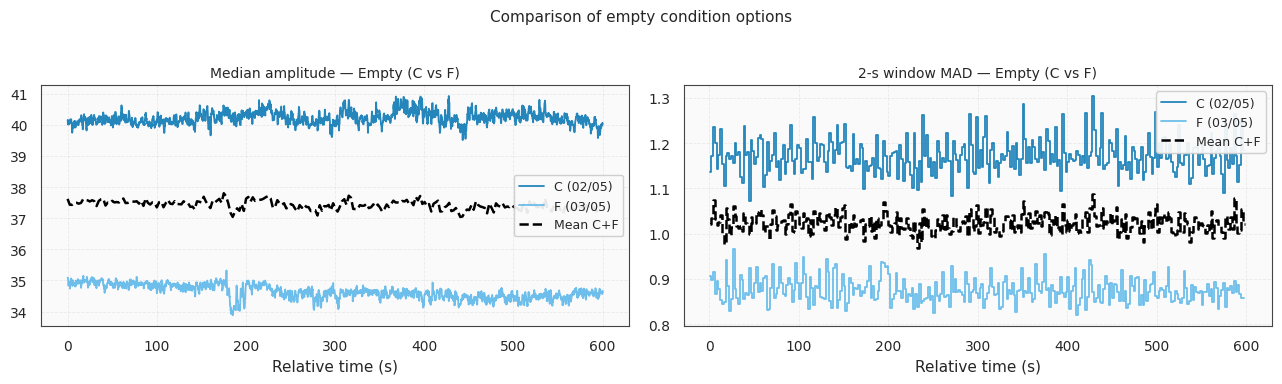

In [14]:
# 6.2  Option B: interpolated average of C and F (no scipy dependency)


def option_empty_averaged(sid_list: list = ['C', 'F'], n_points: int = 1200):
    """
    Interpolate C and F onto a common normalised time grid [0, 600 s]
    and return their point-wise average.
    """
    t_common = np.linspace(0, 600.0, n_points)
    cols = ['median_amp', 'q25_amp', 'q75_amp']
    acc  = {c: [] for c in cols}
    for sid in sid_list:
        df = temporal_stats[sid]
        t  = df['time_s'].values
        for c in cols:
            acc[c].append(np.interp(t_common, t, df[c].values))

    stats_avg = pd.DataFrame({'time_s': t_common})
    for c in cols:
        stats_avg[c] = np.mean(acc[c], axis=0)

    t_win = np.arange(WINDOW_SECONDS / 2, 600.0, WINDOW_SECONDS)
    mad_acc = [np.interp(t_win, window_mad[sid]['window_center_s'].values,
                          window_mad[sid]['mad_agg'].values)
               for sid in sid_list]

    mad_avg = pd.DataFrame({
        'window_center_s': t_win,
        'n_samples':       0,
        'mad_agg':         np.mean(mad_acc, axis=0),
    })
    return stats_avg, mad_avg


# Quick comparison plot: C vs F vs average
_fig_cmp, _axes = plt.subplots(1, 2, figsize=(13, 3.8))
_stats_avg, _mad_avg = option_empty_averaged()

for sid, cor, lbl in [('C', '#0072B2', 'C (02/05)'), ('F', '#56B4E9', 'F (03/05)')]:
    _df  = temporal_stats[sid]
    _dfm = window_mad[sid]
    _axes[0].plot(_df['time_s'].values[::DOWNSAMPLE],
                  _df['median_amp'].values[::DOWNSAMPLE],
                  color=cor, alpha=0.85, lw=1.3, label=lbl)
    _axes[1].step(_dfm['window_center_s'], _dfm['mad_agg'],
                  color=cor, alpha=0.85, lw=1.3, where='mid', label=lbl)

_axes[0].plot(_stats_avg['time_s'].values[::DOWNSAMPLE],
              _stats_avg['median_amp'].values[::DOWNSAMPLE],
              color='black', lw=1.8, ls='--', label='Mean C+F')
_axes[1].step(_mad_avg['window_center_s'], _mad_avg['mad_agg'],
              color='black', lw=1.8, ls='--', where='mid', label='Mean C+F')

for ax, ttl in zip(_axes, ['Median amplitude — Empty (C vs F)',
                             '2-s window MAD — Empty (C vs F)']):
    ax.set_xlabel('Relative time (s)')
    ax.legend(fontsize=9)
    ax.set_title(ttl, fontsize=10)
    ax.grid(True, alpha=0.35)

_fig_cmp.suptitle('Comparison of empty condition options', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()


In [15]:
# 6.3  Final strategy selection

EMPTY_STRATEGY = 'C_only'   # options: 'C_only' | 'F_only' | 'C_F_averaged'

if EMPTY_STRATEGY == 'C_only':
    empty_stats, empty_mad = option_empty_single('C')
    empty_label            = 'Empty (C)'
    empty_session_id       = 'C'
elif EMPTY_STRATEGY == 'F_only':
    empty_stats, empty_mad = option_empty_single('F')
    empty_label            = 'Empty (F)'
    empty_session_id       = 'F'
else:
    empty_stats, empty_mad = option_empty_averaged(['C', 'F'])
    empty_label            = 'Empty (mean C+F)'
    empty_session_id       = None

print(f"Selected strategy : {EMPTY_STRATEGY}")
print(f"Legend label      : {empty_label}")
print(f"Points / windows  : {len(empty_stats):,} / {len(empty_mad)}")


Selected strategy : C_only
Legend label      : Empty (C)
Points / windows  : 17,075 / 299


---
## Section 7 — Final Figure

Two vertically stacked subplots sharing the x-axis (`sharex=True`):
- **Upper panel (height 2×)**: CSI amplitude median line + temporal IQR shaded band
- **Lower panel (height 1×)**: aggregated MAD per 2 s window (step plot)

Colour palette: Okabe-Ito (color-blind safe, grayscale-readable).


In [16]:
# 7.1  Per-condition data dictionary


CONDITIONS = {
    empty_label: {
        'stats': empty_stats,
        'mad':   empty_mad,
        'color': COLOR_EMPTY,
        'alpha': 0.28,
        'lw':    1.6,
    },
    'Occupied moving (E)': {
        'stats': temporal_stats['E'],
        'mad':   window_mad['E'],
        'color': COLOR_MOVING,
        'alpha': 0.28,
        'lw':    1.6,
    },
    'Occupied still (D)': {
        'stats': temporal_stats['D'],
        'mad':   window_mad['D'],
        'color': COLOR_STILL,
        'alpha': 0.28,
        'lw':    1.6,
    },
}

print("Conditions in figure:", list(CONDITIONS.keys()))


Conditions in figure: ['Empty (C)', 'Occupied moving (E)', 'Occupied still (D)']


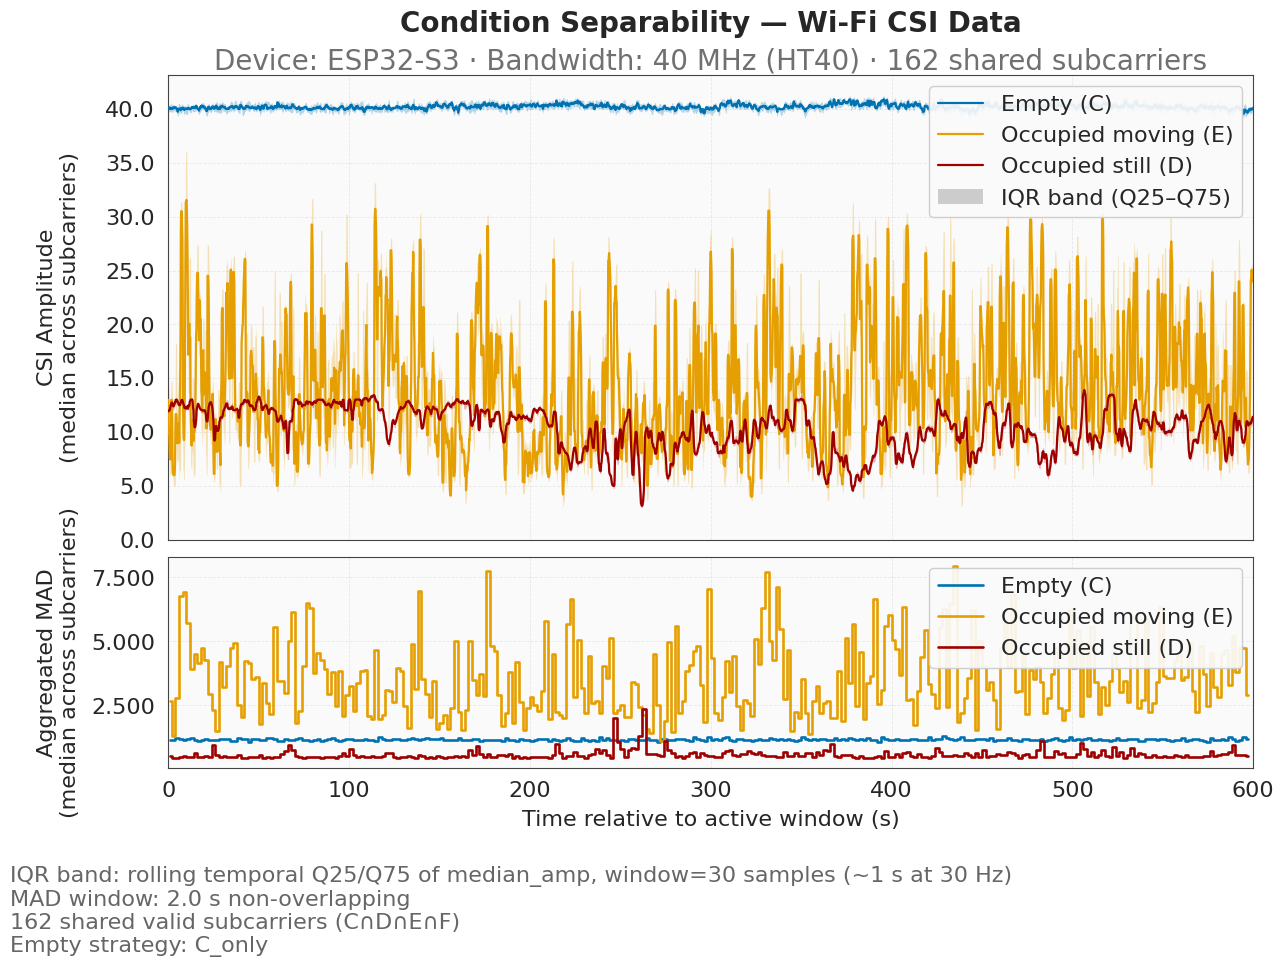

Figure generated.


In [17]:
# 7.2  Generate and display the final figure


fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(14, 9),
    sharex=True,
    gridspec_kw={'height_ratios': [2.2, 1.0], 'hspace': 0.05},
)

for cond_lbl, cdata in CONDITIONS.items():
    st  = cdata['stats']
    mad = cdata['mad']
    c   = cdata['color']
    a   = cdata['alpha']
    lw  = cdata['lw']
    ds  = DOWNSAMPLE

    t_plt   = st['time_s'].values[::ds]
    med_plt = st['median_amp'].values[::ds]
    q25_plt = st['q25_amp'].values[::ds]
    q75_plt = st['q75_amp'].values[::ds]

    # Upper panel: IQR band (behind) + median line (front)
    ax1.fill_between(t_plt, q25_plt, q75_plt, color=c, alpha=a, linewidth=0, zorder=2)
    ax1.plot(t_plt, med_plt, color=c, linewidth=lw, label=cond_lbl, zorder=3)

    # Lower panel: MAD step plot
    ax2.step(mad['window_center_s'], mad['mad_agg'],
             color=c, linewidth=1.9, label=cond_lbl, where='mid', zorder=3)

# --- Upper panel styling ---
ax1.set_ylabel('CSI Amplitude\n(median across subcarriers)', fontsize=16, labelpad=8)
# ax1.set_title(
#     'Condition Separability — Wi-Fi CSI Data  \n'
#     '(ESP32-S3 · HT40 · 162 shared subcarriers)',
#     fontsize=20, fontweight='bold', pad=11,
# )
# Title with two lines — second line in dark gray
ax1.text(0.5, 1.08, 'Condition Separability — Wi-Fi CSI Data',
         ha='center', va='bottom', fontsize=20, fontweight='bold',
         transform=ax1.transAxes)
ax1.text(0.5, 1.00, 'Device: ESP32-S3 · Bandwidth: 40 MHz (HT40) · 162 shared subcarriers',
         ha='center', va='bottom', fontsize=20, fontweight='normal',
         color="#707070",  # dark gray
         transform=ax1.transAxes)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
ax1.tick_params(axis='both', labelsize=16)

# Legend with explicit IQR patch
_line_handles = [
    plt.Line2D([0], [0], color=cdata['color'], lw=cdata['lw'], label=lbl)
    for lbl, cdata in CONDITIONS.items()
]
_iqr_patch = mpatches.Patch(
    facecolor='#888888', alpha=0.40, linewidth=0,
    label=f'IQR band (Q25–Q75)' # — temporal spread, rolling {SMOOTH_WINDOW}-sample window',
)
ax1.legend(handles=_line_handles + [_iqr_patch], loc='upper right',
           fontsize=16, framealpha=0.93)

ax1.set_ylim(bottom=0)  # amplitude can't be negative

# --- Lower panel styling ---
ax2.set_xlabel('Time relative to active window (s)', fontsize=16, labelpad=6)
ax2.set_ylabel('Aggregated MAD\n(median across subcarriers)', fontsize=16, labelpad=8)
ax2.legend(loc='upper right', fontsize=16, framealpha=0.93)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
ax2.tick_params(axis='both', labelsize=16)
ax2.set_xlim(left=0, right=600)

# Footer with pipeline parameters
fig.text(
    0.012, -0.1,
    f'IQR band: rolling temporal Q25/Q75 of median_amp, window={SMOOTH_WINDOW} samples (~1 s at 30 Hz)\n'
    f'MAD window: {WINDOW_SECONDS:.1f} s non-overlapping\n'
    f'{" "*0}{n_shared} shared valid subcarriers (C∩D∩E∩F)\n'
    f'Empty strategy: {EMPTY_STRATEGY}',
    fontsize=16, color='#666666', ha='left', va='bottom',
)

fig.align_ylabels([ax1, ax2])
plt.tight_layout(rect=[0, 0.022, 1, 1])
plt.show()
print("Figure generated.")


---
## Section 8 — Save Outputs

Files exported to `pilot/outputs/figures/`:
- `final_figure.png` — 300 DPI raster
- `final_figure.pdf` — vector (for LaTeX / Word)
- `temporal_series.csv` — window-level statistics for all conditions


In [18]:
# 8.1  Save figure (PNG + PDF)


png_path = OUTPUT_DIR / 'final_figure.png'
pdf_path = OUTPUT_DIR / 'final_figure.pdf'

fig.savefig(png_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"PNG saved: {png_path}  ({png_path.stat().st_size / 1024:.0f} KB)")

try:
    fig.savefig(pdf_path, bbox_inches='tight', facecolor='white')
    print(f"PDF saved: {pdf_path}  ({pdf_path.stat().st_size / 1024:.0f} KB)")
except Exception as _e:
    print(f"PDF not generated ({_e})")


PNG saved: /home/xavier/code/wifi-csi-presence-detection/pilot/outputs/figures/final_figure.png  (1345 KB)
PDF saved: /home/xavier/code/wifi-csi-presence-detection/pilot/outputs/figures/final_figure.pdf  (264 KB)


In [19]:
# 8.2  Export temporal_series.csv — window-level statistics (FIXED v2)
#
#  For each 2-second window:
#    median_amp = median of {median_amp[t]} for all samples t in window
#    q25_amp    = Q25    of {median_amp[t]}   ← temporal Q25 of the scalar signal
#    q75_amp    = Q75    of {median_amp[t]}   ← temporal Q75 of the scalar signal
#
#  All three derived from the same scalar series pm  →  consistent unit.


def build_csv_rows(cond_label: str,
                   session_obj: 'dict | None',
                   mad_df: pd.DataFrame,
                   mask: np.ndarray,
                   stats_df: pd.DataFrame,
                   window_s: float = WINDOW_SECONDS) -> pd.DataFrame:
    """Build window-level CSV rows for one condition."""
    if session_obj is not None:
        amp    = session_obj['amp_matrix'][:, mask]   # (n_samples, 162)
        time_s = session_obj['time_s']
        t, t_end = time_s[0], time_s[-1]
        records = []
        while t + window_s <= t_end + 1e-9:
            m = (time_s >= t) & (time_s < t + window_s)
            if m.sum() >= 2:
                # Scalar signal: per-sample median across 162 subcarriers
                pm = np.median(amp[m], axis=1)   # (n_win_samples,)
                records.append({
                    'condition':       cond_label,
                    'time_s':          t + window_s / 2,
                    'median_amp':      float(np.median(pm)),
                    'q25_amp':         float(np.percentile(pm, 25)),   # temporal Q25
                    'q75_amp':         float(np.percentile(pm, 75)),   # temporal Q75
                    'window_center_s': t + window_s / 2,
                    'mad_agg':         float(np.interp(
                                           t + window_s / 2,
                                           mad_df['window_center_s'].values,
                                           mad_df['mad_agg'].values)),
                })
            t += window_s
        return pd.DataFrame(records)
    else:
        # Averaged option: interpolate already-computed rolling stats
        wc = mad_df['window_center_s'].values
        return pd.DataFrame({
            'condition':       cond_label,
            'time_s':          wc,
            'median_amp':      np.interp(wc, stats_df['time_s'].values,
                                          stats_df['median_amp'].values),
            'q25_amp':         np.interp(wc, stats_df['time_s'].values,
                                          stats_df['q25_amp'].values),
            'q75_amp':         np.interp(wc, stats_df['time_s'].values,
                                          stats_df['q75_amp'].values),
            'window_center_s': wc,
            'mad_agg':         mad_df['mad_agg'].values,
        })


_session_map = {
    'Empty (C)':           'C',
    'Empty (F)':           'F',
    'Empty (mean C+F)':    None,
    'Occupied still (D)':  'D',
    'Occupied moving (E)': 'E',
}

dfs_csv = []
for cond_lbl, cdata in CONDITIONS.items():
    sid  = _session_map.get(cond_lbl)
    sess = sessions.get(sid) if sid else None
    dfs_csv.append(
        build_csv_rows(cond_lbl, sess, cdata['mad'], shared_mask, cdata['stats'])
    )

df_series = pd.concat(dfs_csv, ignore_index=True)
df_series = df_series[['condition', 'time_s', 'median_amp',
                         'q25_amp', 'q75_amp', 'window_center_s', 'mad_agg']]
df_series = df_series.round(6)

csv_path = OUTPUT_DIR / 'temporal_series.csv'
df_series.to_csv(csv_path, index=False)

print(f"CSV saved: {csv_path}")
print(f"  Rows: {len(df_series):,}  |  Columns: {len(df_series.columns)}")

# Post-save diagnostic
print("\nPost-save IQR diagnostic (window-level CSV):")
for cond, g in df_series.groupby('condition'):
    iqr = (g['q75_amp'] - g['q25_amp']).median()
    viol = ((g['q25_amp'] > g['median_amp']) | (g['median_amp'] > g['q75_amp'])).sum()
    print(f"  {cond:<30}  median_amp={g['median_amp'].median():>7.3f}  "
          f"IQR={iqr:>7.4f}  violations={viol}")


CSV saved: /home/xavier/code/wifi-csi-presence-detection/pilot/outputs/figures/temporal_series.csv
  Rows: 897  |  Columns: 7

Post-save IQR diagnostic (window-level CSV):
  Empty (C)                       median_amp= 40.224  IQR= 0.7276  violations=0
  Occupied moving (E)             median_amp= 13.171  IQR= 7.5950  violations=0
  Occupied still (D)              median_amp= 10.757  IQR= 0.7686  violations=0
